<a href="https://colab.research.google.com/github/Matheus0820/Sinais-e-Sistemas/blob/main/unidade01/Trabalho02_Unidade_1_Sinais_e_Sistemas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 2 - Unidade 1
### Objetivo: Rotinas em Python para operações com sinais (soma, multiplicação, contração, expansão e deslocamento).

#### **Aluno:** Matheus Ramos Ferreira da Silva.



# Definindo sinais aleatoriamente

In [1]:
from typing import Literal
# Importando bibliotecas necessárias
import numpy as np
import random

# Definindo tamanho minimo e máximo
tam_min = 10
tam_max = 50

# Gerando vetor aleatório - Sinal
print("== Sinal 1 ==")
s1_tam = random.randint(tam_min, tam_max)
s1_0 = random.randint(0, s1_tam -1)
s1 = (np.random.default_rng().uniform(-10, 10, size = s1_tam)).tolist()
s1_data = (s1_tam, s1_0, s1)

print(f"Tamanho de S1: {s1_tam}")
print(f"Origem de S1: {s1_0}")
print(f"S1: {s1}\n\n")

print("== Sinal 2 ==")
s2_tam = random.randint(tam_min, tam_max)
s2_0 = random.randint(0, s2_tam -1)
s2 = (np.random.default_rng().uniform(-10, 10, size = s2_tam)).tolist()
s2_data = (s2_tam, s2_0, s2)

print(f"Tamanho de S2: {s2_tam}")
print(f"Origem de S2: {s2_0}")
print(f"S2: {s2}")


== Sinal 1 ==
Tamanho de S1: 41
Origem de S1: 34
S1: [6.3870357444384105, -2.537988346058377, -9.286518453435361, 5.106966463441786, -6.788707870263746, 9.980442611711318, 3.940673268158129, -0.7613940320079742, 1.5072024452134052, 9.26048419185318, 1.9788143690352449, -8.376652801782738, -6.733465029923378, -7.936661988666884, -2.559426479274423, -1.1334797401964316, 4.281001369785212, 9.907694634077476, -8.374365917380809, 2.6102814174334643, 3.4967899282297825, -5.823446455018519, -7.794212861319032, -7.718165435489517, 8.420322807479163, 3.101473438114766, 2.4818023936592724, -0.28632968119863556, -6.49838867505764, 3.0222864609399487, 3.4158475038286547, -1.1082795592854353, 2.634375665623349, -9.147254294535811, 2.12563097464818, 2.058056628832169, 1.0556085714659567, -9.830447773985986, 4.537006356924429, -4.521035068221176, 3.4502646417906284]


== Sinal 2 ==
Tamanho de S2: 28
Origem de S2: 11
S2: [9.390024125857241, -1.2284829213203246, 9.926142398045478, -0.32342298047325535,



---



# Plotando Sinais Gerados

 == Sinal 1 == 



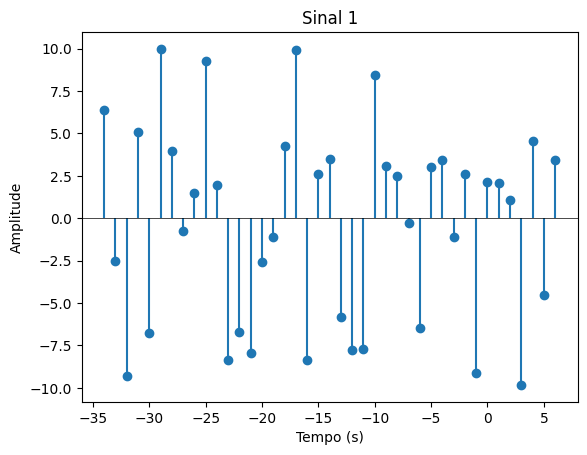



 == Sinal 2  == 



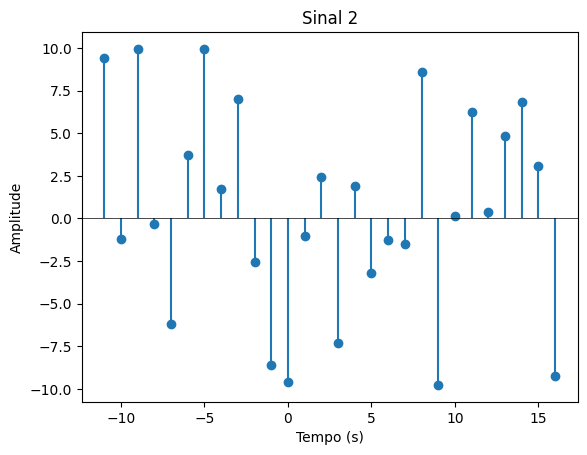

In [2]:
from IPython.utils.tempdir import TemporaryDirectory
# importando biblioteca do Pyplot
import matplotlib.pyplot as plt

# Sabendo que um sinal discreto tem uma distância entre os pontos do eixo horizontal fixa então eu vou definir um T, onde T é esse espaçamento fixo
t = 1

# == Plotando Sinal 1 ==
print(" == Sinal 1 == \n")

# Definindo o array horizontal T1
T1 = []
for i in range(s1_tam):
  T1.append((i - s1_0)*t)

# Plotando o Sinal 1
plt.plot(T1, s1, "o")
plt.vlines(T1, 0, s1)
plt.axhline(0, color='black', linewidth=0.5)
plt.title("Sinal 1")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.show()

# == Plotando Sinal 2 ==
print("\n\n == Sinal 2  == \n")

T2 = []
for i in range(s2_tam):
  T2.append((i - s2_0)*t)

# Plotando o Sinal 2
plt.plot(T2, s2, "o")
plt.vlines(T2, 0, s2)
plt.axhline(0, color='black', linewidth=0.5)
plt.title("Sinal 2")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.show()






---



# Soma entre dois sinais

In [3]:
# Funções auxíliares
def addZerosAtras(sinal, dif_tam):
  for i in range(dif_tam):
    sinal.append(0)

def addZerosFrente(sinal, dif_inicio):
  for i in range(dif_inicio):
    sinal.insert(0, 0)

# == Alinhando Sinais ==
s_soma_index_fim = max(s1_0 + s1_tam - 1, s2_0 + s2_tam - 1)
s_soma_0 = min(s1_0, s2_0) # Origem do sinal resultante da soma
s_soma_tam = s_soma_index_fim - s_soma_0 + 1

s1_copy_sum = s1.copy()
s2_copy_sum = s2.copy()

diferenca_S0s = abs(s1_0 - s2_0)
diferenca_tam = abs(s1_tam - s2_tam)

# Alinhando os inicios dos sinais
if s1_0 > s_soma_0:
  addZerosFrente(s1_copy_sum, s1_0 - s_soma_0)

if s2_0 > s_soma_0:
  addZerosFrente(s2_copy_sum, s2_0 - s_soma_0)

# Alinhando o final
if len(s1_copy_sum) < s_soma_tam:
  addZerosAtras(s1_copy_sum, s_soma_tam - len(s1_copy_sum))

if len(s2_copy_sum) < s_soma_tam:
  addZerosAtras(s2_copy_sum, s_soma_tam - len(s2_copy_sum))


# == Soma ==
# Somando os dois vetores
s_soma = np.array(s1_copy_sum) +  np.array(s2_copy_sum)

# Mostrando o sinal de soma
print("== Sinal de soma ==")
print(f"Tamanho de S: {s_soma_tam}")
print(f"Origem de S: {s_soma_0}")
print(f"S: {s_soma}")


== Sinal de soma ==
Tamanho de S: 64
Origem de S: 11
S: [  9.39002413  -1.22848292   9.9261424   -0.32342298  -6.19326768
   3.71663673   9.94770548   1.7301544    7.00236181  -2.55439287
  -8.58884491  -9.59015013  -1.02758555   2.43089417  -7.3082759
   1.88993701  -3.21770354  -1.27628976  -1.52423119   8.58296094
  -9.76493978   0.17274409   6.25154772   6.77035869   2.29436015
  -2.4355126    8.16509461 -16.02588696   9.98044261   3.94067327
  -0.76139403   1.50720245   9.26048419   1.97881437  -8.3766528
  -6.73346503  -7.93666199  -2.55942648  -1.13347974   4.28100137
   9.90769463  -8.37436592   2.61028142   3.49678993  -5.82344646
  -7.79421286  -7.71816544   8.42032281   3.10147344   2.48180239
  -0.28632968  -6.49838868   3.02228646   3.4158475   -1.10827956
   2.63437567  -9.14725429   2.12563097   2.05805663   1.05560857
  -9.83044777   4.53700636  -4.52103507   3.45026464]




---



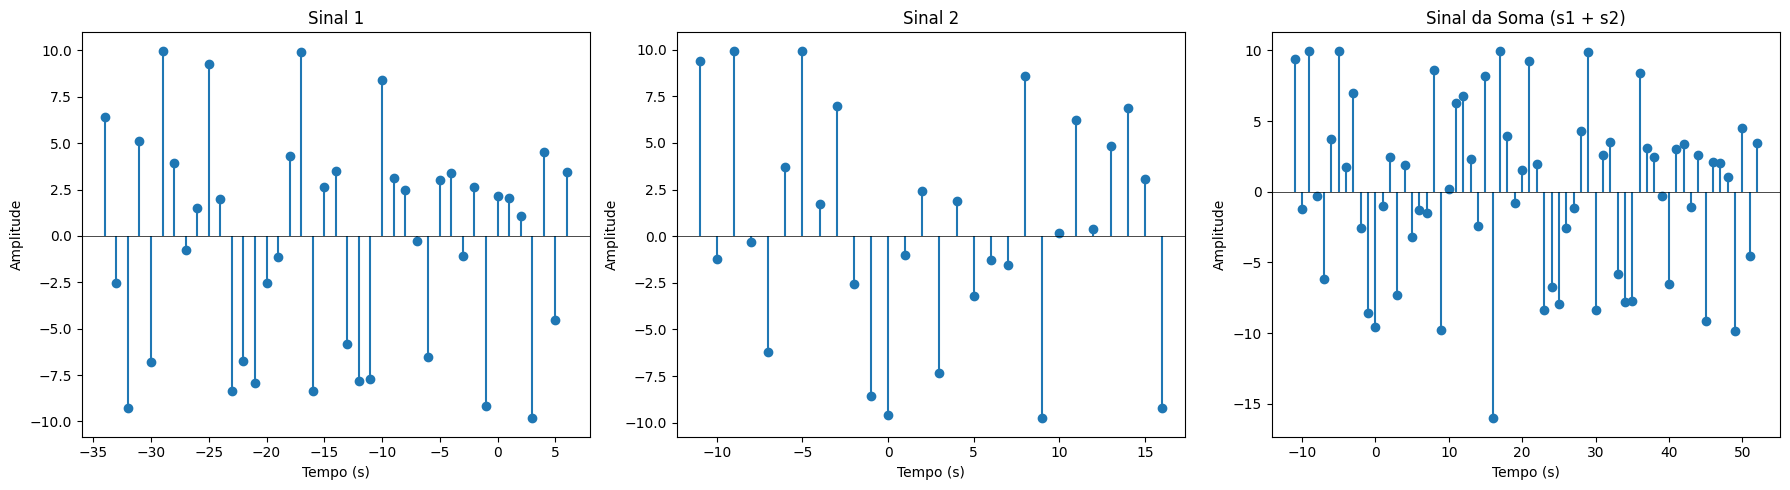

In [4]:
# Plotando sinal da soma
# Criando uma figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 1 linha, 3 colunas

# --- Plotando Sinal 1 ---
axes[0].set_title("Sinal 1")
axes[0].set_xlabel("Tempo (s)")
axes[0].set_ylabel("Amplitude")
axes[0].plot(T1, s1, "o")
axes[0].vlines(T1, 0, s1)
axes[0].axhline(0, color='black', linewidth=0.5)

# --- Plotando Sinal 2 ---
axes[1].set_title("Sinal 2")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("Amplitude")
axes[1].plot(T2, s2, "o")
axes[1].vlines(T2, 0, s2)
axes[1].axhline(0, color='black', linewidth=0.5)

# --- Plotando Sinal da Soma ---
axes[2].set_title("Sinal da Soma (s1 + s2)")
axes[2].set_xlabel("Tempo (s)")
axes[2].set_ylabel("Amplitude")

T_soma = []
for i in range(s_soma_tam):
  T_soma.append((i - s_soma_0)*t)

axes[2].plot(T_soma, s_soma, "o")
axes[2].vlines(T_soma, 0, s_soma)
axes[2].axhline(0, color='black', linewidth=0.5)

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

# Multiplicação entre sinais

In [5]:
# == Alinando sinais ==
s1_copy_mult = s1.copy()
s2_copy_mult = s2.copy()

s_mult_index_fim = max(s1_0 + (s1_tam - 1), s2_0 + (s2_tam -1))
s_mult_0 = min(s1_0, s2_0)
s_mult_tam = s_mult_index_fim - s_mult_0 + 1

# Alinhar os inicios do sinais
if s1_0 > s_mult_0:
  addZerosFrente(s1_copy_mult, s1_0 - s_mult_0)

if s2_0 > s_mult_0:
  addZerosFrente(s2_copy_mult, s2_0 - s_mult_0)

# Alinhando o final dos sinais
if len(s1_copy_mult) < s_mult_tam:
  addZerosAtras(s1_copy_mult, s_mult_tam - len(s1_copy_mult))

if len(s2_copy_mult) < s_mult_tam:
  addZerosAtras(s2_copy_mult, s_mult_tam - len(s2_copy_mult))

# == Multiplicação ==
print("== Sinais ==")
print(f"{s1_copy_mult}")
print(f"{s2_copy_mult}")

print("== Sinal de multiplicação ==")
s_mult = np.array(s1_copy_mult) * np.array(s2_copy_mult)
print(f"{s_mult_tam}")
print(f"{s_mult_0}")
print(f"{s_mult}")

== Sinais ==
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6.3870357444384105, -2.537988346058377, -9.286518453435361, 5.106966463441786, -6.788707870263746, 9.980442611711318, 3.940673268158129, -0.7613940320079742, 1.5072024452134052, 9.26048419185318, 1.9788143690352449, -8.376652801782738, -6.733465029923378, -7.936661988666884, -2.559426479274423, -1.1334797401964316, 4.281001369785212, 9.907694634077476, -8.374365917380809, 2.6102814174334643, 3.4967899282297825, -5.823446455018519, -7.794212861319032, -7.718165435489517, 8.420322807479163, 3.101473438114766, 2.4818023936592724, -0.28632968119863556, -6.49838867505764, 3.0222864609399487, 3.4158475038286547, -1.1082795592854353, 2.634375665623349, -9.147254294535811, 2.12563097464818, 2.058056628832169, 1.0556085714659567, -9.830447773985986, 4.537006356924429, -4.521035068221176, 3.4502646417906284]
[9.390024125857241, -1.2284829213203246, 9.926142398045478, -0.32342298047325535, -6.193267679126501, 3.716

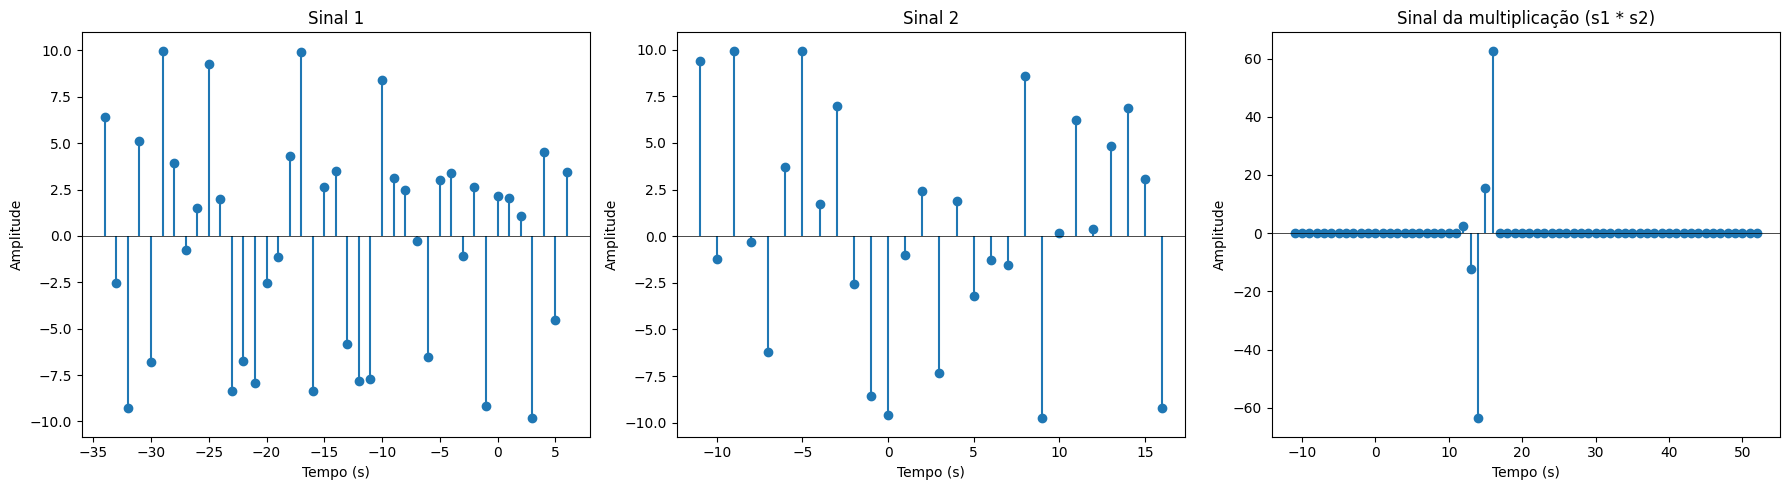

In [6]:
# Plotando o sinal da multiplicação
# Criando uma figura com 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# == Plotando Sinal 1 ==
axes[0].set_title("Sinal 1")
axes[0].set_xlabel("Tempo (s)")
axes[0].set_ylabel("Amplitude")
axes[0].plot(T1, s1, "o")
axes[0].vlines(T1, 0, s1)
axes[0].axhline(0, color='black', linewidth=0.5)

# == Plotando Sinal 2 ==
axes[1].set_title("Sinal 2")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("Amplitude")
axes[1].plot(T2, s2, "o")
axes[1].vlines(T2, 0, s2)
axes[1].axhline(0, color='black', linewidth=0.5)

# == Plotando Sinal da multiplicação ==
T_mult = []
for i in range(s_mult_tam):
  T_mult.append((i - s_mult_0)*t)

axes[2].set_title("Sinal da multiplicação (s1 * s2)")
axes[2].set_xlabel("Tempo (s)")
axes[2].set_ylabel("Amplitude")
axes[2].plot(T_mult, s_mult, "o")
axes[2].vlines(T_mult, 0, s_mult)
axes[2].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()




---



# Contração de Sinais



In [7]:
# Bibliotecas usadas
import math

def contrairSinal(sinal, n, s_0):
  sinal_contraido = []
  sinal_contraido_tam = int(len(sinal)/n)
  sinal_contraido_0 = int(math.ceil(s_0/n))

  for i in range(sinal_contraido_tam):
    sinal_contraido.append(sinal[i])

  return sinal_contraido, sinal_contraido_tam, sinal_contraido_0



Tamanho de S1 Contraido: 20
Origem de S1 Contraido: 17
S1 Contraido: [6.3870357444384105, -2.537988346058377, -9.286518453435361, 5.106966463441786, -6.788707870263746, 9.980442611711318, 3.940673268158129, -0.7613940320079742, 1.5072024452134052, 9.26048419185318, 1.9788143690352449, -8.376652801782738, -6.733465029923378, -7.936661988666884, -2.559426479274423, -1.1334797401964316, 4.281001369785212, 9.907694634077476, -8.374365917380809, 2.6102814174334643]



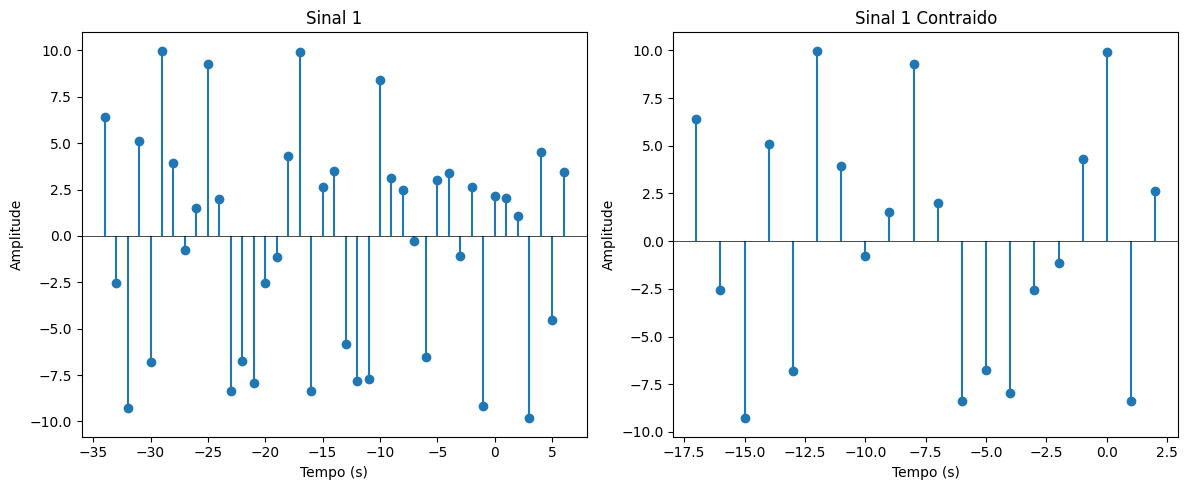

In [8]:
# == Contraindo S1 ==
n = 2
s1_contraido, s1_contraido_tam, s1_contraido_0 = contrairSinal(s1, n, s1_0)

print(f"Tamanho de S1 Contraido: {s1_contraido_tam}")
print(f"Origem de S1 Contraido: {s1_contraido_0}")
print(f"S1 Contraido: {s1_contraido}\n")

# Plotando S1 Contraido ao lado do S1 original
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotando Sinal 1
axes[0].set_title("Sinal 1")
axes[0].set_xlabel("Tempo (s)")
axes[0].set_ylabel("Amplitude")
axes[0].plot(T1, s1, "o")
axes[0].vlines(T1, 0, s1)
axes[0].axhline(0, color='black', linewidth=0.5)

# Plotando Sinal 1 Contraido
T1_contraido = []

for i in range(s1_contraido_tam):
  T1_contraido.append((i - s1_contraido_0)*t)

axes[1].set_title("Sinal 1 Contraido")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("Amplitude")
axes[1].plot(T1_contraido, s1_contraido, "o")
axes[1].vlines(T1_contraido, 0, s1_contraido)
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

S2 contraido Tamanho: 14
S2 contraido Origem: 6
S2 Contraido: [9.390024125857241, -1.2284829213203246, 9.926142398045478, -0.32342298047325535, -6.193267679126501, 3.7166367261170397, 9.947705484158622, 1.7301543958060854, 7.002361809113758, -2.5543928722783775, -8.58884490871156, -9.590150133699755, -1.0275855464698864, 2.430894168934131]



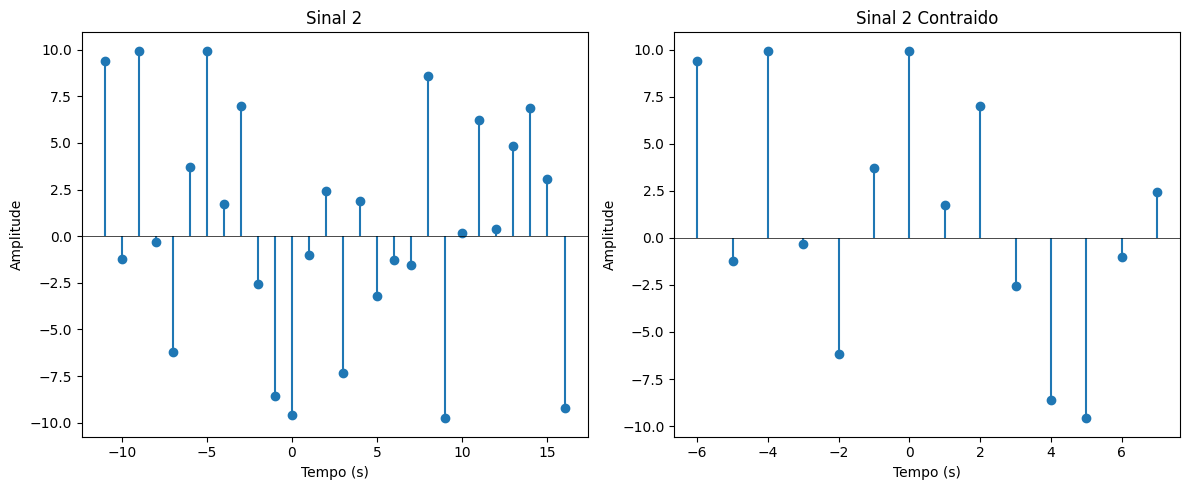

In [9]:
# == Contraindo S2 ==
n = 2
s2_contraido, s2_contraido_tam, s2_contraido_0 = contrairSinal(s2, n, s2_0)

print(f"S2 contraido Tamanho: {s2_contraido_tam}")
print(f"S2 contraido Origem: {s2_contraido_0}")
print(f"S2 Contraido: {s2_contraido}\n")

# Plotando Sinal 2 contraido
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotando Sinal 2
axes[0].set_title("Sinal 2")
axes[0].set_xlabel("Tempo (s)")
axes[0].set_ylabel("Amplitude")
axes[0].plot(T2, s2, "o")
axes[0].vlines(T2, 0, s2)
axes[0].axhline(0, color='black', linewidth=0.5)

# Plotando Sinal 2 Contraido
T2_contraido = []
for i in range(s2_contraido_tam):
  T2_contraido.append((i - s2_contraido_0)*t)

axes[1].set_title("Sinal 2 Contraido")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("Amplitude")
axes[1].plot(T2_contraido, s2_contraido, "o")
axes[1].vlines(T2_contraido, 0, s2_contraido)
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()



---



# Expansão de Sinal

In [10]:
# == Função Expansão ==

def expandirSinal(sinal, n, s_0):
  sinal_expandido = []
  sinal_expandido_tam = int(len(sinal)*n)
  sinal_expandido_0 = int(math.floor(s_0*n))

  for i in range(sinal_expandido_tam):
    sinal_expandido.append(0)

  for i in range(sinal_expandido_tam):
    if i%n == 0:
      sinal_expandido[i] = sinal[int(i/n)]

  return sinal_expandido, sinal_expandido_tam, sinal_expandido_0


Tamanho de S1 Expandido: 82
Origem de S1 Expandido: 68
S1 Expandido: [6.3870357444384105, 0, -2.537988346058377, 0, -9.286518453435361, 0, 5.106966463441786, 0, -6.788707870263746, 0, 9.980442611711318, 0, 3.940673268158129, 0, -0.7613940320079742, 0, 1.5072024452134052, 0, 9.26048419185318, 0, 1.9788143690352449, 0, -8.376652801782738, 0, -6.733465029923378, 0, -7.936661988666884, 0, -2.559426479274423, 0, -1.1334797401964316, 0, 4.281001369785212, 0, 9.907694634077476, 0, -8.374365917380809, 0, 2.6102814174334643, 0, 3.4967899282297825, 0, -5.823446455018519, 0, -7.794212861319032, 0, -7.718165435489517, 0, 8.420322807479163, 0, 3.101473438114766, 0, 2.4818023936592724, 0, -0.28632968119863556, 0, -6.49838867505764, 0, 3.0222864609399487, 0, 3.4158475038286547, 0, -1.1082795592854353, 0, 2.634375665623349, 0, -9.147254294535811, 0, 2.12563097464818, 0, 2.058056628832169, 0, 1.0556085714659567, 0, -9.830447773985986, 0, 4.537006356924429, 0, -4.521035068221176, 0, 3.4502646417906284, 

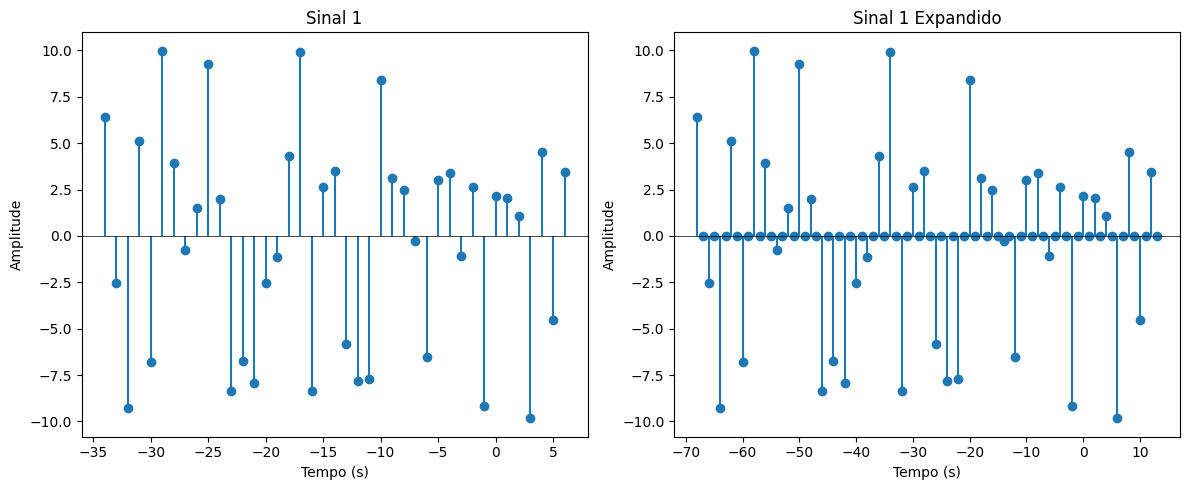

In [11]:
# == Expandindo Sinal 1 ==
n = 2
s1_expandido, s1_expandido_tam, s1_expandido_0 = expandirSinal(s1, n, s1_0)

print(f"Tamanho de S1 Expandido: {s1_expandido_tam}")
print(f"Origem de S1 Expandido: {s1_expandido_0}")
print(f"S1 Expandido: {s1_expandido}\n")

# Plotando Sinal 1 expandido
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotando Sinal 1
axes[0].set_title("Sinal 1")
axes[0].set_xlabel("Tempo (s)")
axes[0].set_ylabel("Amplitude")
axes[0].plot(T1, s1, "o")
axes[0].vlines(T1, 0, s1)
axes[0].axhline(0, color='black', linewidth=0.5)

# Plotando Sinal 1 Expandido
T1_expandido = []
for i in range(s1_expandido_tam):
  T1_expandido.append((i - s1_expandido_0)*t)

axes[1].set_title("Sinal 1 Expandido")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("Amplitude")
axes[1].plot(T1_expandido, s1_expandido, "o")
axes[1].vlines(T1_expandido, 0, s1_expandido)
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

Tamanho do S2 Expandido: 56
Origem do S2 Expandido: 22
S2 Expandido: [9.390024125857241, 0, -1.2284829213203246, 0, 9.926142398045478, 0, -0.32342298047325535, 0, -6.193267679126501, 0, 3.7166367261170397, 0, 9.947705484158622, 0, 1.7301543958060854, 0, 7.002361809113758, 0, -2.5543928722783775, 0, -8.58884490871156, 0, -9.590150133699755, 0, -1.0275855464698864, 0, 2.430894168934131, 0, -7.30827589897215, 0, 1.8899370136736025, 0, -3.217703537395618, 0, -1.2762897637916577, 0, -1.5242311908607125, 0, 8.58296094247245, 0, -9.764939776530017, 0, 0.17274408997348623, 0, 6.251547719929778, 0, 0.3833229407797951, 0, 4.832348499517172, 0, 6.8510058526968045, 0, 3.05812814391928, 0, -9.237179088420804, 0]



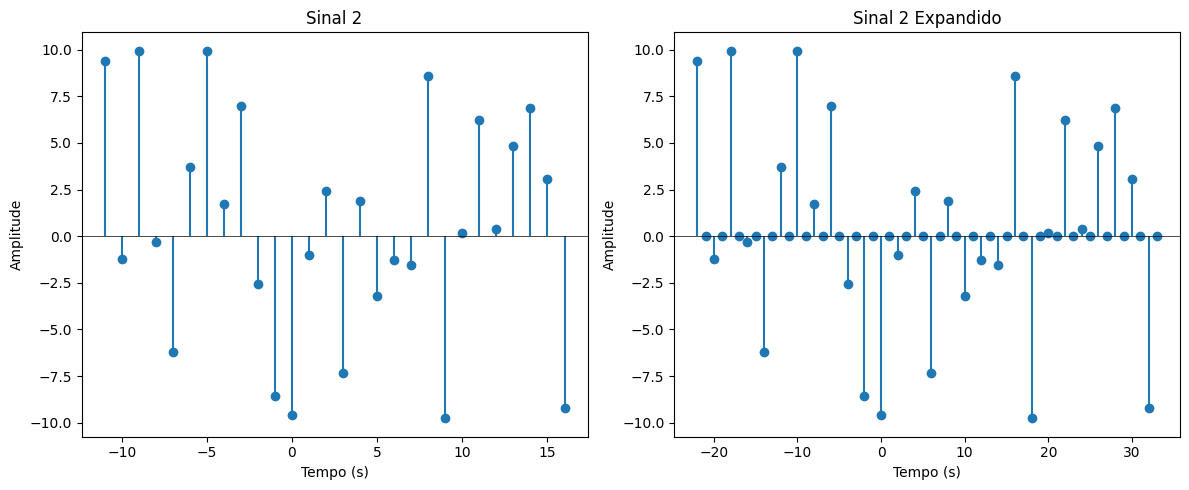

In [12]:
# == Expandindo Sinal 2 ==
n = 2
s2_expandido, s2_expandido_tam, s2_expandido_0 = expandirSinal(s2, n, s2_0)

print(f"Tamanho do S2 Expandido: {s2_expandido_tam}")
print(f"Origem do S2 Expandido: {s2_expandido_0}")
print(f"S2 Expandido: {s2_expandido}\n")

# Plotando o Sinal 2 Expandido
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotando Sinal 2
axes[0].set_title("Sinal 2")
axes[0].set_xlabel("Tempo (s)")
axes[0].set_ylabel("Amplitude")
axes[0].plot(T2, s2, "o")
axes[0].vlines(T2, 0, s2)
axes[0].axhline(0, color='black', linewidth=0.5)

# Sinal 2 Expandido
T2_expandido = []
for i in range(s2_expandido_tam):
  T2_expandido.append((i - s2_expandido_0)*t)

axes[1].set_title("Sinal 2 Expandido")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("Amplitude")
axes[1].plot(T2_expandido, s2_expandido, "o")
axes[1].vlines(T2_expandido, 0, s2_expandido)
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()



---



# Deslocamento de Origem de Sinal

In [13]:
# Função de deslocamento
def deslocarSinal(sinal, n, s_0):
  sinal_deslocado = sinal.copy()
  sinal_deslocado_tam = len(sinal) + abs(n)
  diferenca_deslocamento = abs(n)

  if n > s_0:
    sinal_deslocado_0 = 0
  else:
    sinal_deslocado_0 = s_0 - n

  if n < 0: # Se n for menor que zero o ponto inicial será deslocado para a direita
    if abs(n) > len(sinal) - s_0:

      print(f"Adicionou 0s no final -> {n - (len(sinal) - s_0)} 0s adicionados")

    for i in range(diferenca_deslocamento):
      sinal_deslocado.append(0)
  elif n > 0: # Se n for maior que zero o ponto inicial será deslocado para a esquerda
    if n < s_0:
      print(f"Adicionou 0s no início -> {abs(n - s_0)} 0s adicionados")

    for i in range(diferenca_deslocamento):
      sinal_deslocado.insert(0, 0)

  return sinal_deslocado, sinal_deslocado_tam, sinal_deslocado_0;


Origem do Sinal 1: 34 -> 2.12563097464818
Tamanho do Sinal 1 deslocado: 43
Origem do Sinal 1 deslocado: 36
Sinal 1 deslocado: [6.3870357444384105, -2.537988346058377, -9.286518453435361, 5.106966463441786, -6.788707870263746, 9.980442611711318, 3.940673268158129, -0.7613940320079742, 1.5072024452134052, 9.26048419185318, 1.9788143690352449, -8.376652801782738, -6.733465029923378, -7.936661988666884, -2.559426479274423, -1.1334797401964316, 4.281001369785212, 9.907694634077476, -8.374365917380809, 2.6102814174334643, 3.4967899282297825, -5.823446455018519, -7.794212861319032, -7.718165435489517, 8.420322807479163, 3.101473438114766, 2.4818023936592724, -0.28632968119863556, -6.49838867505764, 3.0222864609399487, 3.4158475038286547, -1.1082795592854353, 2.634375665623349, -9.147254294535811, 2.12563097464818, 2.058056628832169, 1.0556085714659567, -9.830447773985986, 4.537006356924429, -4.521035068221176, 3.4502646417906284, 0, 0]



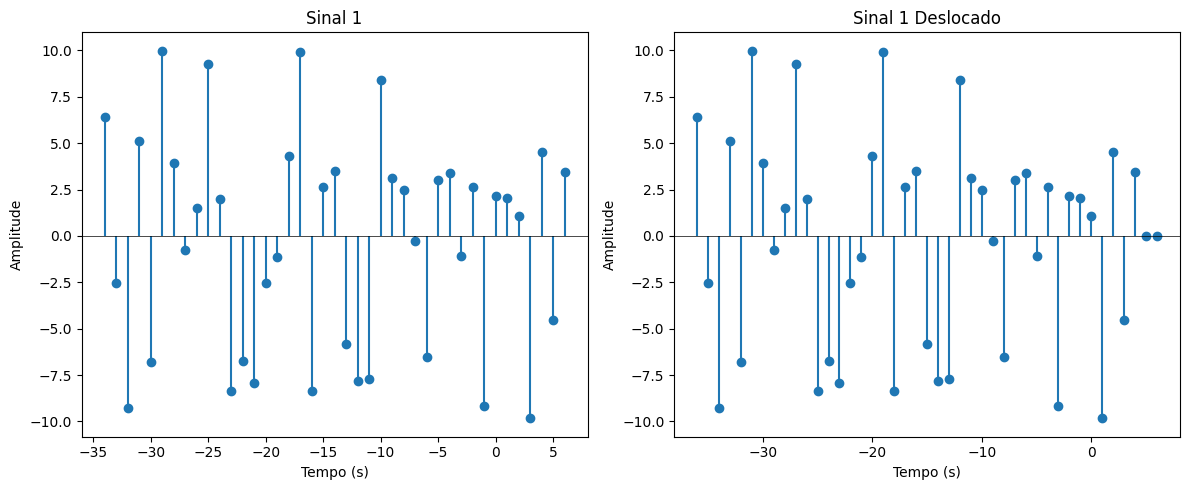

In [14]:
# == Deslocando Sinal 1 ==
n = -2
s1_deslocado, s1_deslocado_tam, s1_deslocado_0 = deslocarSinal(s1, n, s1_0)

print(f"Origem do Sinal 1: {s1_0} -> {s1[s1_0]}")

print(f"Tamanho do Sinal 1 deslocado: {s1_deslocado_tam}")
print(f"Origem do Sinal 1 deslocado: {s1_deslocado_0}")
print(f"Sinal 1 deslocado: {s1_deslocado}\n")

# Plotando sinais
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotando Sinal 1
axes[0].set_title("Sinal 1")
axes[0].set_xlabel("Tempo (s)")
axes[0].set_ylabel("Amplitude")
axes[0].plot(T1, s1, "o")
axes[0].vlines(T1, 0, s1)
axes[0].axhline(0, color='black', linewidth=0.5)

# Plotando Sinal 1 deslocado
T1_deslocado = []
for i in range(s1_deslocado_tam):
  T1_deslocado.append((i - s1_deslocado_0)*t)

axes[1].set_title("Sinal 1 Deslocado")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("Amplitude")
axes[1].plot(T1_deslocado, s1_deslocado, "o")
axes[1].vlines(T1_deslocado, 0, s1_deslocado)
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

Adicionou 0s no início -> 9 0s adicionados
Origem do Sinal 2: 11 -> -9.590150133699755
Tamanho do Sinal 2 deslocado: 30
Origem do Sinal 2 deslocado: 9
Sinal 2 deslocado: [0, 0, 9.390024125857241, -1.2284829213203246, 9.926142398045478, -0.32342298047325535, -6.193267679126501, 3.7166367261170397, 9.947705484158622, 1.7301543958060854, 7.002361809113758, -2.5543928722783775, -8.58884490871156, -9.590150133699755, -1.0275855464698864, 2.430894168934131, -7.30827589897215, 1.8899370136736025, -3.217703537395618, -1.2762897637916577, -1.5242311908607125, 8.58296094247245, -9.764939776530017, 0.17274408997348623, 6.251547719929778, 0.3833229407797951, 4.832348499517172, 6.8510058526968045, 3.05812814391928, -9.237179088420804]


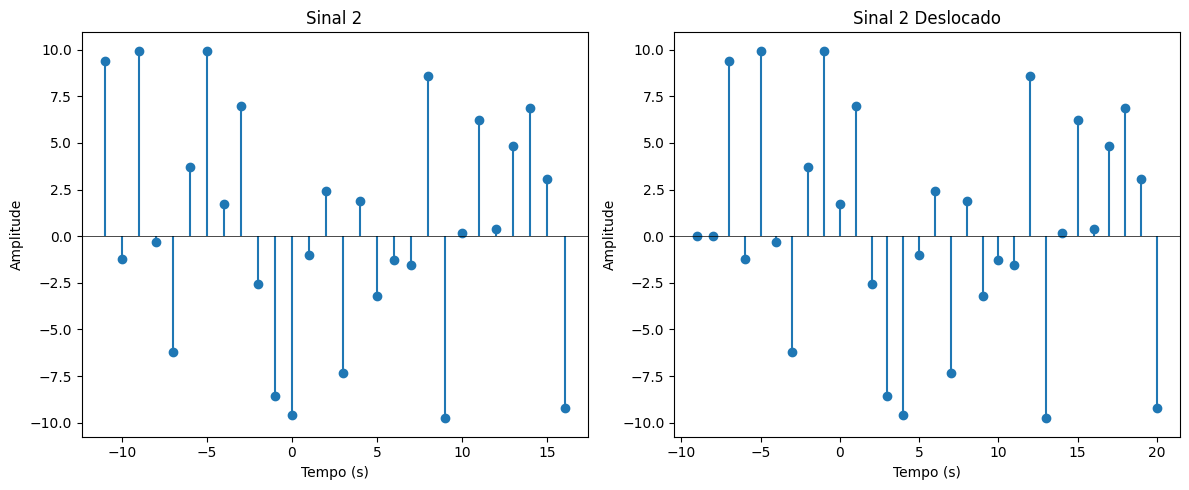

In [15]:
# == Deslocando Sinal 2 ==
n = 2
s2_deslocado, s2_deslocado_tam, s2_deslocado_0 = deslocarSinal(s2, n, s2_0)

print(f"Origem do Sinal 2: {s2_0} -> {s2[s2_0]}")

print(f"Tamanho do Sinal 2 deslocado: {s2_deslocado_tam}")
print(f"Origem do Sinal 2 deslocado: {s2_deslocado_0}")
print(f"Sinal 2 deslocado: {s2_deslocado}")

# Plotando Sinais
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotando Sinal 2
axes[0].set_title("Sinal 2")
axes[0].set_xlabel("Tempo (s)")
axes[0].set_ylabel("Amplitude")
axes[0].plot(T2, s2, "o")
axes[0].vlines(T2, 0, s2)
axes[0].axhline(0, color='black', linewidth=0.5)

# Plotando o Sinal deslocado
T2_deslocado = []
for i in range(s2_deslocado_tam):
  T2_deslocado.append((i - s2_deslocado_0)*t)

axes[1].set_title("Sinal 2 Deslocado")
axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("Amplitude")
axes[1].plot(T2_deslocado, s2_deslocado, "o")
axes[1].vlines(T2_deslocado, 0, s2_deslocado)
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()